This notebook contains the code for a CNN LSTM model from scratch. The plus side is there is no freezing unfreezing. The model we consider hee is a very simple architecture. We saw that pre-trained models with complicated architectures did not perform as anticipated. And this may work even better than the TN model we had trained, or maybe this will have the worst performance of all. 

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import matplotlib.pyplot as plt

2025-03-12 10:25:43.158790: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-12 10:25:43.987895: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-12 10:25:43.987956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-12 10:25:44.199197: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-12 10:25:44.484510: I tensorflow/core/platform/cpu_feature_guar

In [2]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# Need to first locate the train data and stack them to be used in the network

# the train blocks are 101, 102, 203, and 301

# We also need the validation data, but since it is block 204, we can leave that data as it is

# Stacking the train data might take a lot of memory, and we might have to stack it in a job

# Let's try it here initially though

# location of all data
all_data_loc = 'All_data'

# train blocks
train_blocks = ['block_0101', 'block_0102', 'block_0203', 'block_0301']

In [4]:
# get the density maps and the corresponding image subwindows so that they can be stacked for the train data
all_feature_subwindow_names = []
all_density_map_names =[]

for folder_name in train_blocks:
    path_name = os.path.join(all_data_loc, folder_name)
    density_map = [file for file in os.listdir(path_name)if file[:7] == 'density']
    feature_map = [file for file in os.listdir(path_name)if file[:7] == 'subwind']
    all_feature_subwindow_names.append(feature_map)
    all_density_map_names.append(density_map)
    

In [5]:
# load all feature maps
all_feature_maps = []
counter = 0
for item in np.array(all_feature_subwindow_names).flatten():
    load_map = np.load(os.path.join(all_data_loc, train_blocks[counter], item))
    all_feature_maps.append(load_map)
    counter = counter + 1

In [6]:
# load density maps
all_density_maps = []
counter = 0
for map in np.array(all_density_map_names).flatten():
    load_density_map = np.load(os.path.join(all_data_loc, train_blocks[counter], map))
    all_density_maps.append(load_density_map)
    counter = counter + 1

In [7]:
# check the shape of an item
all_density_maps[0].shape, all_feature_maps[0].shape

((12288, 7), (12288, 13, 32, 32, 3))

In [8]:
# how many items in each list?
len(all_density_maps), len(all_feature_maps)

(4, 4)

In [9]:
# stack all data together?

# I think we need to stack vertically
all_train_density_maps = np.vstack(all_density_maps)

all_train_feature_maps = np.vstack(all_feature_maps)

In [10]:
# check these shapes
all_train_density_maps.shape, all_train_feature_maps.shape

((49152, 7), (49152, 13, 32, 32, 3))

In [11]:
# we may need to do a sanity check to know if we have correctly stacked
for i in range(4):
    print(np.mean(all_density_maps[i] == all_train_density_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [12]:
# for feature maps
for i in range(4):
    print(np.mean(all_feature_maps[i] == all_train_feature_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [13]:
# Okay, we have stacked the data correctly. Let's not store these data separately and proceed with the train script

In [14]:
# Also need to load the validation data

# list the contents in the validation folder
all_valid_contents = os.listdir("All_data/block_0204")

In [15]:
all_valid_contents

['all_np_files',
 'subwindow_seqs_0204.npy',
 '.ipynb_checkpoints',
 'density_maps_seqs_0204.npy']

In [16]:
validation_feature_maps = np.load(os.path.join("All_data/block_0204", 'subwindow_seqs_0204.npy'))

In [17]:
validation_density_map = np.load(os.path.join("All_data/block_0204", 'density_maps_seqs_0204.npy'))

In [18]:
validation_feature_maps.shape, validation_density_map.shape

((12288, 13, 32, 32, 3), (12288, 7))

In [19]:
# Define the from scratch CNN LSTM model architecture

In [20]:
# Write the body of the CNN LSTM

# input layer
input_layer = tf.keras.layers.Input((None,None,None,3))

# cnn layer
# cnn layer
cnn_input = tf.keras.layers.Input((None, None, 3))
first_conv_layer = tf.keras.layers.Conv2D(32, (3, 3), padding = "same")
first_conv_out = first_conv_layer(cnn_input)
second_conv_layer = tf.keras.layers.Conv2D(32, (3, 3), padding = "same")
second_conv_out = second_conv_layer(first_conv_out)
third_conv_layer = tf.keras.layers.Conv2D(64, (3, 3), padding = "same")
third_conv_out = third_conv_layer(second_conv_out)
fourth_conv_layer = tf.keras.layers.Conv2D(64, (3, 3), padding = "same")
fourth_conv_out = fourth_conv_layer(third_conv_out)

global_max_pool = tf.keras.layers.GlobalMaxPooling2D()
global_max_pool_out = global_max_pool(fourth_conv_out)

cnn_model = tf.keras.models.Model(cnn_input, global_max_pool_out)

cnn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 conv2d_2 (Conv2D)           (None, None, None, 64)    18496     
                                                                 
 conv2d_3 (Conv2D)           (None, None, None, 64)    36928     
                                                                 
 global_max_pooling2d (Glob  (None, 64)                0         
 alMaxPooling2D)                                                 
                                                             

2025-03-12 10:27:12.209480: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:06:00.0, compute capability: 7.0


In [21]:
time_dist_layer = tf.keras.layers.TimeDistributed(cnn_model)

time_dist_output = time_dist_layer(input_layer)
time_dist_output

<KerasTensor: shape=(None, None, 64) dtype=float32 (created by layer 'time_distributed')>

In [22]:
lstm_layer = tf.keras.layers.LSTM(64)
lstm_output = lstm_layer(time_dist_output)
lstm_output

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'lstm')>

In [23]:
# pred_layer_td = tf.keras.layers.TimeDistributed()
pred_layer = tf.keras.layers.Dense(7, activation = "relu")
# pred_time_dist_layer = tf.keras.layers.TimeDistributed(pred_layer)
pred_layer_out = pred_layer(lstm_output)
pred_layer_out

<KerasTensor: shape=(None, 7) dtype=float32 (created by layer 'dense')>

In [24]:
cnn_lstm = tf.keras.models.Model(input_layer, pred_layer_out)
cnn_lstm.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, Non   0         
                             e, 3)]                              
                                                                 
 time_distributed (TimeDist  (None, None, 64)          65568     
 ributed)                                                        
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 7)                 455       
                                                                 
Total params: 99047 (386.90 KB)
Trainable params: 99047 (386.90 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


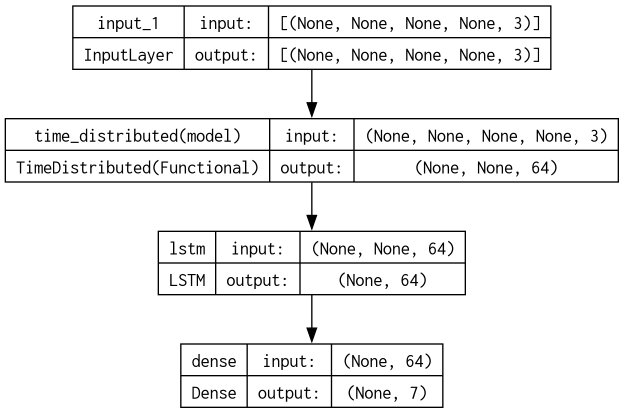

In [25]:
tf.keras.utils.plot_model(cnn_lstm, show_shapes = True)

In [26]:
# Define and add the generator function
def data_generator(x_data, y_data, batch_size, shuffle=False, peek=False, verbose=False):
    num_samples = len(x_data)
    indices = np.arange(num_samples)
    
    if peek:    # Give first batch unshuffled and don't change start index when peeking for training
        end = min(batch_size, num_samples)
        if verbose:
            print(f"Generating peeking batch up to index {end}")
        batch_x = x_data[:end]
        batch_y = y_data[:end]
        peek = False
        yield (batch_x, batch_y)

    while True:    # Loop indefinitely for epochs
        # Shuffle indices at the start of each epoch after the peek, if shuffle is enabled
        if shuffle:
            np.random.shuffle(indices)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]

            # Print batch indices if verbose
            if verbose:
                # Warning: calling verbose when shuffling will usually clutter output
                if shuffle:
                    if len(batch_indices) < 16:
                        print(f"Batch indices: {np.sort(batch_indices)}")
                    else:
                        print(f"Printing batch indices would clutter output. Skipped.")
                    print(f"Length: {len(batch_indices)}")
                else:
                    print(f"Generating batch from index {start} to {end}")
                # traceback.print_stack()

            # Generate batches
            batch_x = x_data[batch_indices]
            batch_y = y_data[batch_indices]

            # Yield the current batch
            yield (batch_x, batch_y)

In [27]:
%%time
batch_size = 64
generator_batch_size = 64
train_gen = data_generator(all_train_feature_maps, all_train_density_maps, batch_size, shuffle=False, peek=True, verbose=False)
val_gen = data_generator(validation_feature_maps, validation_density_map, generator_batch_size, shuffle=False, peek=True, verbose=False)

CPU times: user 3 µs, sys: 5 µs, total: 8 µs
Wall time: 13.6 µs


In [28]:
steps_per_epoch = int(np.ceil(len(all_train_feature_maps) / batch_size))
train_steps = int(np.ceil(len(all_train_feature_maps) / generator_batch_size))
validation_steps = int(np.ceil(len(validation_feature_maps) / generator_batch_size))

In [29]:
%%time
# compile the model
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
cnn_lstm.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])
    
# add early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=20)

# fit the generator - the steps are a must here
history = cnn_lstm.fit(train_gen,
          validation_data = val_gen, steps_per_epoch=steps_per_epoch, 
                                  validation_steps=validation_steps,           
          epochs = 100, callbacks = [es])

Epoch 1/100


2025-03-12 10:27:19.583354: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-03-12 10:27:23.063333: I external/local_xla/xla/service/service.cc:168] XLA service 0x14563c3d9450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-12 10:27:23.063370: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-12 10:27:23.173803: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741793243.801245   89550 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


768/768 [==============================] - 39s 36ms/step - loss: 0.0308 - mean_absolute_error: 0.0523 - val_loss: 0.0168 - val_mean_absolute_error: 0.0322
Epoch 2/100
768/768 [==============================] - 28s 36ms/step - loss: 0.0292 - mean_absolute_error: 0.0561 - val_loss: 0.0162 - val_mean_absolute_error: 0.0340
Epoch 3/100
768/768 [==============================] - 28s 36ms/step - loss: 0.0280 - mean_absolute_error: 0.0573 - val_loss: 0.0167 - val_mean_absolute_error: 0.0418
Epoch 4/100
768/768 [==============================] - 28s 36ms/step - loss: 0.0277 - mean_absolute_error: 0.0565 - val_loss: 0.0173 - val_mean_absolute_error: 0.0453
Epoch 5/100
768/768 [==============================] - 28s 36ms/step - loss: 0.0275 - mean_absolute_error: 0.0560 - val_loss: 0.0178 - val_mean_absolute_error: 0.0472
Epoch 6/100
768/768 [==============================] - 28s 36ms/step - loss: 0.0273 - mean_absolute_error: 0.0557 - val_loss: 0.0175 - val_mean_absolute_error: 0.0467
Epoch 7/10

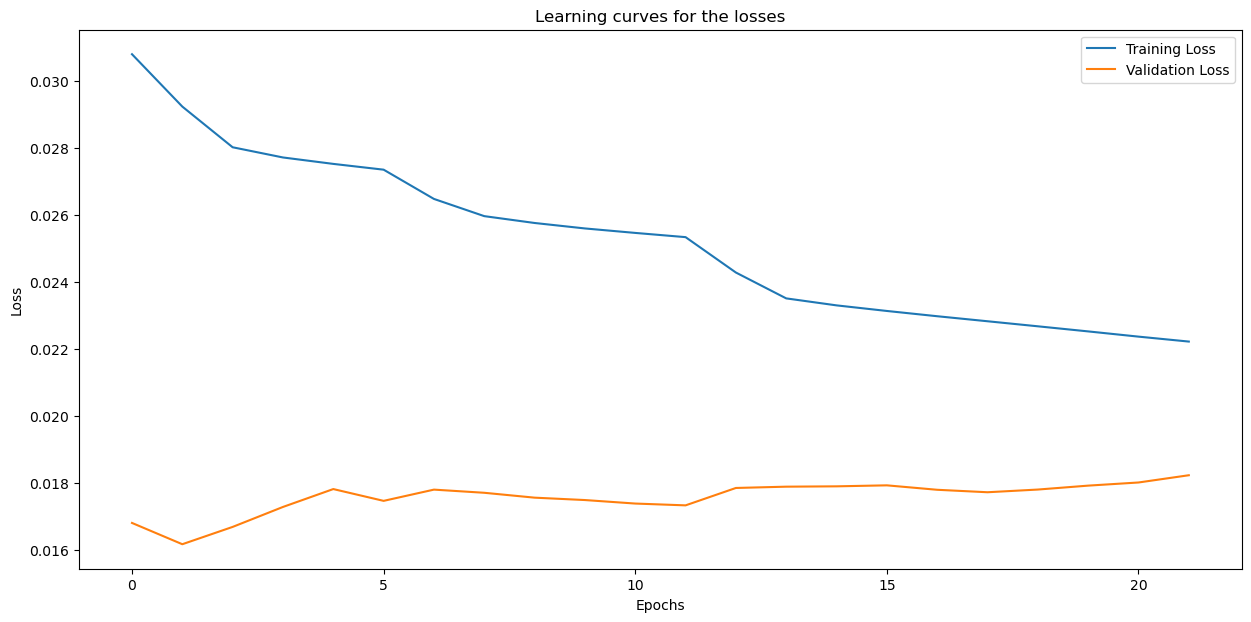

In [30]:
# plot the losses
plt.figure(figsize = (15,7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Learning curves for the losses")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# history.history['loss']

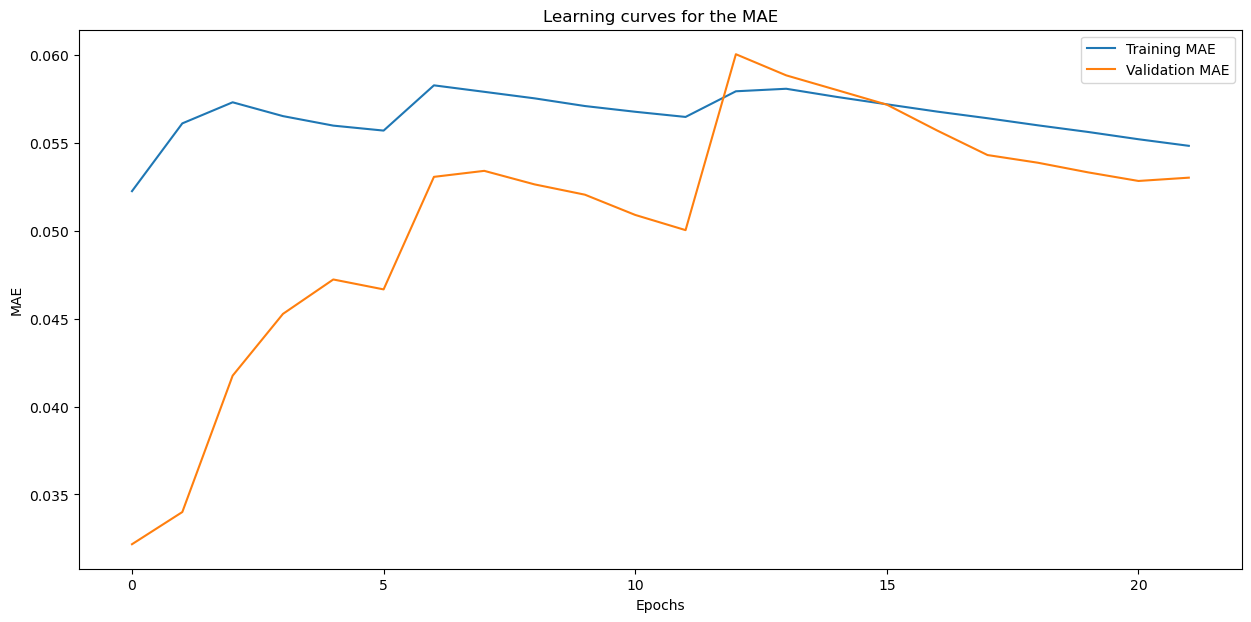

In [31]:
# plot the maes
plt.figure(figsize = (15,7))
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title("Learning curves for the MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [32]:
# save this model
model_name_frozen = 'CNN_LSTM_from_scratch.keras'
cnn_lstm.save('models' + '/' + model_name_frozen)